In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

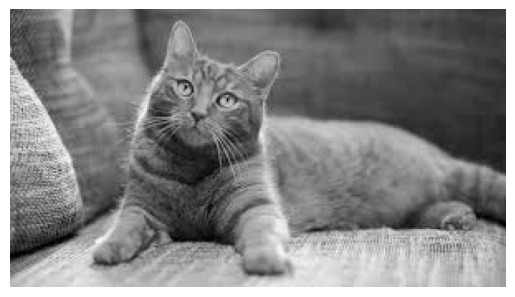

In [4]:
img = cv2.imread('cat.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

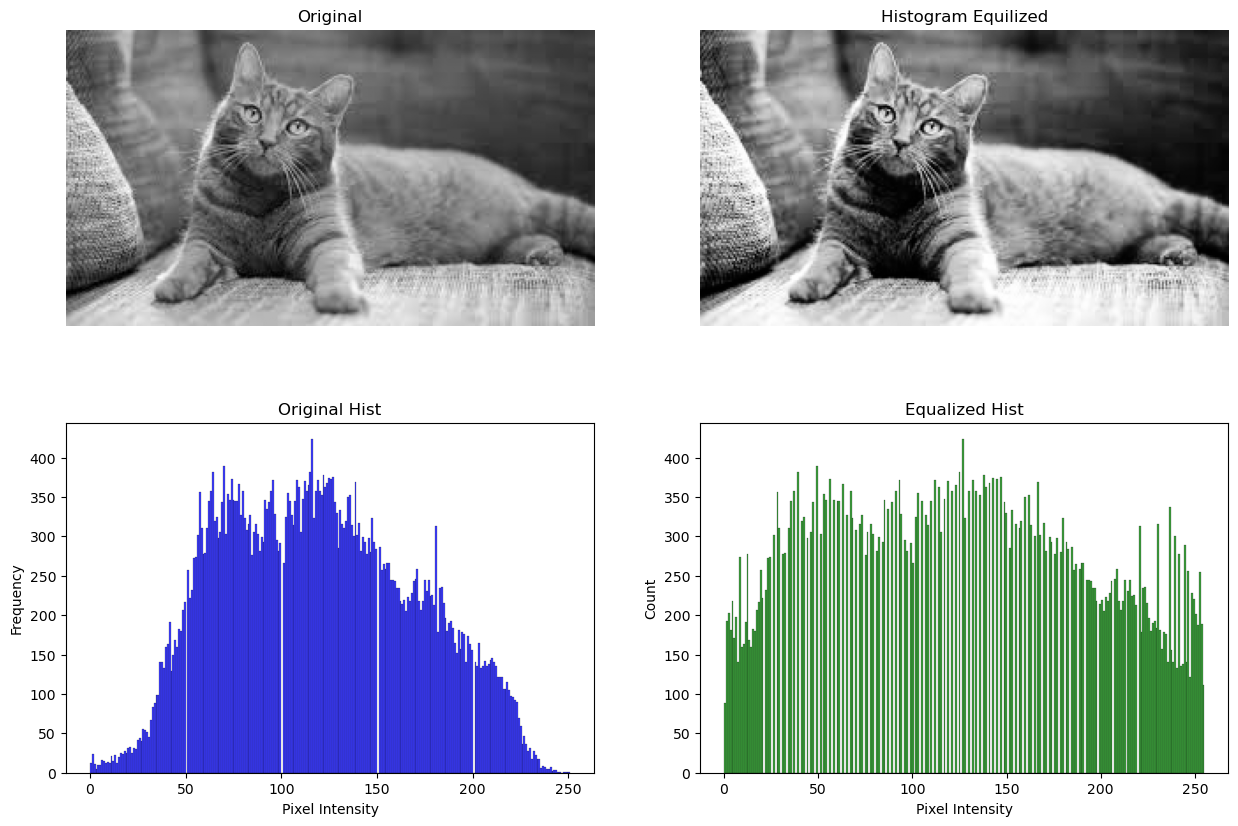

In [18]:
# Step 1 : Histogram

# Create zero array
hist = np.zeros(255)

for pixel in gray.flatten():
   hist[pixel] += 1

# Step 2 : Normalize the histogram
hist = hist/gray.size

# Step 3: CDF
cdf = np.cumsum(hist)

# Step 4 : Mapping --> using formula [new_values = (L-1).CDF(old_value)]
# round() --> For Scalars(single numbers)
# numpy.round() --> For arrays(element-wise operation)
new_values = np.round(255*cdf).astype(np.uint8)

# Replace with old_values --> new_values (replace pixels)
# Replace every pixel value p in the image with new_values[p], which equals cdf(p) * 255.
# for each pixel p in gray:
    # replace p with new_values[p]

equilized = new_values[gray]

# Display
plt.figure(figsize=(15,10))

# Original Image
plt.subplot(2,2,1)
plt.imshow(gray, cmap ='gray')
plt.axis('off')
plt.title("Original")

# Equalized Image
plt.subplot(2,2,2)
plt.imshow(equilized, cmap ='gray')
plt.axis('off')
plt.title("Histogram Equilized")

# Original Histogram
plt.subplot(2,2,3)
sns.histplot(gray.flatten(), bins = 256, color ='blue')
plt.title("Original Hist")
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Equalized Histogram
plt.subplot(2,2,4)
sns.histplot(equilized.flatten(), bins = 256, color ='green')
plt.title("Original Hist")
plt.xlabel('Pixel Intensity')
plt.title("Equalized Hist")


plt.show()